In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Background nucleosome-score windows
nuc_array_path = "binding_score_at_motifs/background_nucleosome_arrays/global_nuc_bg_prom_n7.npy"

# Binding-score tables at motifs
erg_binding_df_path = "binding_score_at_motifs/ERG/ERG__orig-human__loc-prom__motif-GABPA.H12CORE.0.PSM.A__type-family__fl25__nuc-7-25-50__trim150.csv"
atf1_binding_df_path = "binding_score_at_motifs/ATF1/ATF1__orig-human__loc-prom__motif-BATF3.H12CORE.2.SM.B__type-family__fl25__nuc-7-25-50__trim150.csv"

# Background binding-score windows
erg_bg_windows_path = "binding_score_at_motifs/background_binding_arrays/ERG__orig-human__loc-prom__signal_bg__fl25.npy"
atf1_bg_windows_path = "binding_score_at_motifs/background_binding_arrays/ATF1__orig-human__loc-prom__signal_bg__fl25.npy"


## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

## Data Loading

In [4]:
# Load background nucleosome score windows
nuc_array = np.load(nuc_array_path, mmap_mode=None)

# Load binding-score tables for the two panels
erg_binding_df = pd.read_csv(erg_binding_df_path)
atf1_binding_df = pd.read_csv(atf1_binding_df_path)

# Load background binding-score windows
erg_bg_windows = np.load(erg_bg_windows_path, mmap_mode=None)
erg_bg_z     = erg_bg_windows[:,1]

atf1_bg_windows = np.load(atf1_bg_windows_path, mmap_mode=None)
atf1_bg_z     = atf1_bg_windows[:,1]

## Helper Functions

In [5]:
# Return only the extreme nucleosome bins used in the plot
def _nuc_bins_extremes(series, cutoffs):
    cuts = sorted(np.unique(cutoffs))
    if len(cuts) == 0:
        return ["All"], [pd.Series(True, index=series.index if hasattr(series, "index") else None)]

    low = cuts[0]
    high = cuts[1] if len(cuts) >= 2 else cuts[-1]

    labels = [f"<{low}", f">{high}"]
    masks = [series < low, series > high]
    return labels, masks

## Plotting

In [6]:
# Plot the fraction of motif windows above threshold in two panels
def plot_pct_vs_threshold_groups_by_nuc_two_panel(
    z_arrays, nuc_arrays, dfs,
    cutoffs=None, z_col="z_score", nuc_col="nuc_score_f7",
    plot_both_backgrounds=False,
    figsize=(12, 4),
    titles=None,
):

    if len(z_arrays) != 2 or len(nuc_arrays) != 2 or len(dfs) != 2:
        raise ValueError("Provide exactly two z_arrays, two nuc_arrays, and two dfs.")

    if titles is not None and len(titles) != 2:
        raise ValueError("`titles` must be a list/tuple of length 2.")

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    for i, (ax, z_array, nuc_array, df) in enumerate(
        zip(axes, z_arrays, nuc_arrays, dfs)
    ):

        if cutoffs is None or (hasattr(cutoffs, "__len__") and len(cutoffs) == 0):
            labels, df_masks = ["All"], [pd.Series(True, index=df.index)]
            bg_labels, bg_masks = ["All"], [np.ones(len(z_array), dtype=bool)]
        else:
            labels, df_masks = _nuc_bins_extremes(
                pd.to_numeric(df[nuc_col], errors="coerce"), cutoffs
            )
            bg_labels, bg_masks = _nuc_bins_extremes(
                pd.to_numeric(pd.Series(nuc_array), errors="coerce"), cutoffs
            )

        z_bg_global = np.sort(
            pd.to_numeric(pd.Series(z_array), errors="coerce").dropna().to_numpy()
        )

        qs = np.linspace(0.0, 1.0, 1000)

        def _compute_curves(use_bin_specific):
            curves_local = []
            x_edges_local = []
            for label, m_df, m_bg in zip(labels, df_masks, bg_masks):
                if use_bin_specific:
                    z_bg = np.sort(np.asarray(z_array)[m_bg])
                else:
                    z_bg = z_bg_global

                if z_bg.size == 0:
                    continue

                thr_base = np.quantile(z_bg, qs)
                z = np.sort(
                    pd.to_numeric(df.loc[m_df, z_col], errors="coerce")
                    .dropna()
                    .to_numpy()
                )
                if z.size == 0:
                    continue

                tmax = np.nextafter(max(z_bg.max(), z.max()), np.inf)
                thr = np.r_[thr_base, tmax]

                x = (z_bg.size - np.searchsorted(z_bg, thr, "left")) / z_bg.size
                y = (z.size   - np.searchsorted(z,    thr, "left")) / z.size

                pos = np.flatnonzero(y > 0)
                if pos.size:
                    x_edges_local.append(x[pos[-1]])

                curves_local.append((label, len(z), x, y))
            return curves_local, x_edges_local

        # Always use bin-specific background
        curves, x_edges = _compute_curves(True)

        curves_global = []
        if plot_both_backgrounds:
            curves_global, x_edges_global = _compute_curves(False)
            x_edges = x_edges + x_edges_global

        eps = 0.0

        line_handles = {}
        for label, n, x, y in curves:
            line, = ax.plot(x, y, label=f"{label} (n={n})")
            line_handles[label] = line

        if plot_both_backgrounds and curves_global:
            for label, n, x, y in curves_global:
                base_line = line_handles.get(label)
                if base_line is not None:
                    ax.plot(
                        x, y,
                        alpha=0.15,
                        color=base_line.get_color(),
                        label="_nolegend_"
                    )

        ax.plot(
            [0.0, 1.0],
            [0.0, 1.0],
            "--", lw=0.8, color="lightgray"
        )

        ax.set_xlabel("Background ≥ threshold", fontsize=12)
        ax.grid(alpha=0.2)
        ax.set_xlim(-0.01, 1.0)
        ax.set_ylim(0.0, 1.0)

        ax.xaxis.set_major_locator(MultipleLocator(0.25))
        ax.yaxis.set_major_locator(MultipleLocator(0.25))

        fmt = FuncFormatter(lambda v, pos: f"{v:.1f}" if abs((v * 2) % 1) < 1e-9 else "")
        ax.xaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_formatter(fmt)

        ax.legend(
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.435, 0),
            fontsize=12,
            handlelength=1.0,
            handletextpad=0.4,
        )

        if titles is not None:
            ax.set_title(titles[i], fontsize=16)

    axes[0].set_ylabel("Motifs ≥ thresh.", labelpad=-1, fontsize=12)

    plt.tight_layout()
    plt.show()

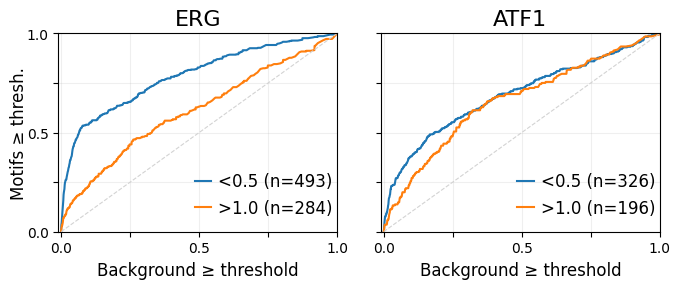

In [7]:
# Generate the requested two-panel plot
plot_pct_vs_threshold_groups_by_nuc_two_panel(
    z_arrays=[erg_bg_z, atf1_bg_z],
    nuc_arrays=[nuc_array, nuc_array],
    dfs=[erg_binding_df, atf1_binding_df],
    titles=["ERG", "ATF1"],
    cutoffs=[0.5, 1.0],
    z_col="z_score",
    nuc_col="nuc_score_f7",
    plot_both_backgrounds=False,
    figsize=(7, 3),
)